## Training script

In [20]:
# Jupyter notebook auto reload
%load_ext autoreload
%autoreload 2

import json
import torch
import torch.nn as nn
import torch.optim as optim
from char_tokenizer import TinyArithmeticCharTokenizer
from tiny_transformer import TinyArithmeticTransformer
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training on device: cpu


Loading dataset, adding "=" between input and output, tokenization, and adding padding

In [21]:
tokenizer = TinyArithmeticCharTokenizer()

with open("dataset.json", "r") as f:
    raw_data = json.load(f)

tokenized_sequences = []
for expression, result in raw_data:
    full_str = f"{expression}={result}<eos>"
    encoded_ids = tokenizer.encode(full_str)
    tokenized_sequences.append(encoded_ids)

max_seq_len = 256
pad_id = tokenizer.char_to_int["<pad>"]

padded_sequences = []
for seq in tokenized_sequences:
    if len(seq) < max_seq_len:
        seq = seq + [pad_id] * (max_seq_len - len(seq))
    else:
        seq = seq[:max_seq_len]
    padded_sequences.append(seq)

dataset_tensor = torch.tensor(padded_sequences, dtype=torch.long)

In [23]:
print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(dataset_tensor[:1])

Dataset securely loaded in-memory. Matrix shape: torch.Size([10000, 256])
tensor([[ 4,  6, 15,  0,  9, 16, 10, 16, 11,  1,  3, 15,  9,  3, 16, 13, 16, 11,
          3,  1, 15,  1, 16, 11, 16,  4,  2, 15,  9, 16, 11, 16, 11,  3,  6, 15,
          3,  4, 16, 10, 16,  4,  9, 15,  9,  9, 16, 12, 16, 11,  9,  4, 15,  1,
          4, 16, 13, 16,  5,  9, 15,  4,  7, 16, 10, 16, 11,  1, 15,  5,  9, 16,
         12, 16, 11,  4,  2, 15,  4,  9, 14,  2,  8, 15,  4, 19, 19, 19, 19, 19,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17

Preparing training, validation, testing datasets.

In [24]:
total_rows = dataset_tensor.size(0)

train_percent = 0.80
val_percent   = 0.10
test_percent  = 0.10

train_size = int(train_percent * total_rows)
val_size   = int(val_percent * total_rows)
test_size  = total_rows - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    dataset_tensor, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64
max_seq_len = 256
num_heads = 4

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train Loader: {len(train_loader)} batches (Total: {len(train_subset)} shuffled rows)")
print(f"Val Loader:   {len(val_loader)} batches (Total: {len(val_subset)} shuffled rows)")
print(f"Test Loader:  {len(test_loader)} batches (Total: {len(test_subset)} shuffled rows)")

Train Loader: 125 batches (Total: 8000 shuffled rows)
Val Loader:   16 batches (Total: 1000 shuffled rows)
Test Loader:  16 batches (Total: 1000 shuffled rows)


Helper function to compute the loss mask. Later when calculating loss, since our prefix inputs is full attention and sees every token, we dont want to calculate loss for prefix tokens. We also don't want to calculate loss for <pad> after our <eos>. This loss mask will produce a [0, 1] float dtype mask so we zero out the loss from tokens we dont care about, leaving only the loss updates for the output tokens and <eos>.

In [25]:
def compute_loss_mask(targets: torch.Tensor, eq_token_id: int, pad_token_id: int) -> torch.Tensor:
    batch_size, seq_len = targets.shape
    
    eq_indices = (targets == eq_token_id).int().argmax(dim=-1).view(batch_size, 1)
    pos_grid = torch.arange(seq_len, device=targets.device).view(1, seq_len)
    
    is_after_eq = (pos_grid > eq_indices)
    is_not_pad  = (targets != pad_token_id)
    
    loss_mask = (is_after_eq & is_not_pad).float().view(-1)
    return loss_mask


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

vocab_size   = tokenizer.vocab_size  
eq_token_id  = tokenizer.char_to_int["="]     
pad_token_id = tokenizer.char_to_int["<pad>"] 

model     = TinyArithmeticTransformer(vocab_size=vocab_size, max_seq_len=max_seq_len, num_heads=num_heads).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
loss_fct  = nn.CrossEntropyLoss(reduction='none')

train_loss_history = []
val_loss_history = []


def plot_live_loss(train_history, val_history, current_epoch, total_target_epochs):
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs_range = range(1, len(train_history) + 1)
    
    ax.plot(epochs_range, train_history, label='Training Loss', color='royalblue', linewidth=2, marker='o')
    ax.plot(epochs_range, val_history, label='Validation Loss', color='darkorange', linewidth=2, marker='s')
    
    ax.set_title('Live Training and Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax.set_xticks(epochs_range)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    
    print(f"Latest Stats -> Epoch {current_epoch:02d}/{total_target_epochs:02d} | "
          f"Train Loss: {train_history[-1]:.4f} | Val Loss: {val_history[-1]:.4f}")


def train_model(num_epochs_to_add: int):
    start_epoch = len(train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add
    
    for epoch in range(start_epoch, target_epoch):
        model.train()
        total_train_loss = 0.0
        
        for batch_sequences in train_loader:
            batch_sequences = batch_sequences.to(device)
            
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()
            
            attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
            
            optimizer.zero_grad()
            logits = model(inputs, mask=attn_mask)
            
            raw_loss          = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
            loss_mask         = compute_loss_mask(targets, eq_token_id, pad_token_id)
            num_active_tokens = loss_mask.sum()
            
            loss = (raw_loss * loss_mask).sum() / max(num_active_tokens.item(), 1.0)
            
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_sequences in val_loader:
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()
                
                attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
                logits    = model(inputs, mask=attn_mask)
                
                raw_loss  = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss_mask = compute_loss_mask(targets, eq_token_id, pad_token_id)
                
                val_loss = (raw_loss * loss_mask).sum() / max(loss_mask.sum().item(), 1.0)
                total_val_loss += val_loss.item()
                
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss   = total_val_loss / len(val_loader)
        
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)
        
        # plotting losses
        plot_live_loss(
            train_history=train_loss_history, 
            val_history=val_loss_history, 
            current_epoch=epoch + 1, 
            total_target_epochs=target_epoch
        )

Training on device: cpu


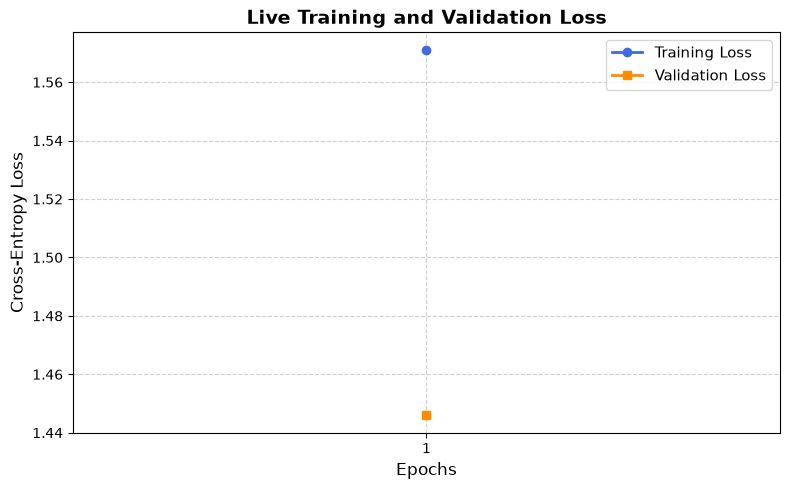

Latest Stats -> Epoch 01/20 | Train Loss: 1.5709 | Val Loss: 1.4462


In [ ]:
train_model(num_epochs_to_add=20)